In [18]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import imutils
from tqdm import tqdm
from skimage.feature import hog
from skimage.color import rgb2gray
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import numpy as np
import pandas as pd
from collections import Counter
import random
import itertools
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from classifier import unique

# I. Tiền xử lý dữ liệu

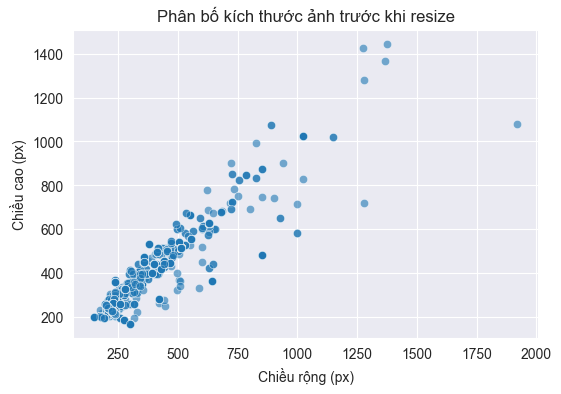

Tổng số ảnh: 7023
Chiều rộng trung bình: 445.9px
Chiều cao trung bình: 448.3px


In [2]:
# --- Đường dẫn gốc ---
BASE_DIR = os.getcwd()
raw_root = os.path.join(BASE_DIR, "data", "raw")
training = os.path.join(raw_root, "Training")
testing = os.path.join(raw_root, "Testing")

# --- Kiểm tra 1 ảnh mẫu ---
sample_class = os.listdir(training)[0]
sample_img_name = os.listdir(os.path.join(training, sample_class))[0]

raw_img_path = os.path.join(training, sample_class, sample_img_name)
cleaned_img_path = os.path.join(BASE_DIR, "data", "cleaned", "Training", sample_class, sample_img_name)

# --- Duyệt toàn bộ ảnh trong raw ---
image_paths = []
for split_dir in [training, testing]:
    for class_name in os.listdir(split_dir):
        class_dir = os.path.join(split_dir, class_name)
        if not os.path.isdir(class_dir):
            continue
        for fname in os.listdir(class_dir):
            if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                image_paths.append(os.path.join(class_dir, fname))

# --- Lấy kích thước ảnh ---
original_shapes = []
for path in image_paths:
    try:
        with Image.open(path) as img:
            original_shapes.append(img.size)  # (width, height)
    except Exception as e:
        print(f"Lỗi đọc {path}: {e}")

# --- Vẽ phân bố ---
if original_shapes:
    widths, heights = zip(*original_shapes)

    plt.figure(figsize=(6,4))
    sns.scatterplot(x=widths, y=heights, alpha=0.6)
    plt.title("Phân bố kích thước ảnh trước khi resize")
    plt.xlabel("Chiều rộng (px)")
    plt.ylabel("Chiều cao (px)")
    plt.show()

    print(f"Tổng số ảnh: {len(original_shapes)}")
    print(f"Chiều rộng trung bình: {sum(widths)/len(widths):.1f}px")
    print(f"Chiều cao trung bình: {sum(heights)/len(heights):.1f}px")
else:
    print("Không tìm thấy ảnh hợp lệ trong thư mục raw.")

## 1. Làm sạch dữ liệu

In [3]:
# HÀM CẮT ẢNH THEO VÙNG CHÍNH
def crop_img(img):
    """
    Cắt ảnh để loại bỏ vùng nền dư thừa, chỉ giữ lại phần chứa vật thể chính.
    Các bước:
        1. Chuyển ảnh sang thang xám (grayscale).
        2. Làm mờ ảnh để giảm nhiễu.
        3. Ngưỡng hoá (threshold) để tách vật thể ra khỏi nền.
        4. Dò các đường biên (contours) và chọn contour lớn nhất.
        5. Xác định toạ độ biên trên - dưới - trái - phải của contour.
        6. Cắt ảnh theo các biên đó để lấy vùng vật thể chính.
    """
    # Chuyển ảnh sang thang xám và làm mờ
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    # Ngưỡng hóa để tách vật thể ra khỏi nền
    thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)

    # Tìm contour lớn nhất (vật thể chính)
    cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutils.grab_contours(cnts)
    c = max(cnts, key=cv2.contourArea)

    # Lấy các điểm biên của contour
    extLeft = tuple(c[c[:, :, 0].argmin()][0])
    extRight = tuple(c[c[:, :, 0].argmax()][0])
    extTop = tuple(c[c[:, :, 1].argmin()][0])
    extBot = tuple(c[c[:, :, 1].argmax()][0])

    # Cắt ảnh theo vùng vật thể chính
    return img[extTop[1]:extBot[1], extLeft[0]:extRight[0]].copy()


# CHUẨN BỊ ĐƯỜNG DẪN VÀ THAM SỐ XỬ LÝ
training = os.path.join(BASE_DIR, "data", "raw", "Training")  # Thư mục chứa ảnh train gốc
testing = os.path.join(BASE_DIR, "data", "raw", "Testing")  # Thư mục chứa ảnh test gốc
IMG_SIZE = 128  # Kích thước chuẩn của ảnh sau xử lý

print("Training path:", training)
print("Testing path:", testing)

# XỬ LÝ TỪNG TẬP DỮ LIỆU (TRAINING & TESTING)
for dataset, name in [(training, "Training"), (testing, "Testing")]:
    print(f"\nĐang xử lý tập {name}...")

    # Lặp qua từng thư mục con (mỗi thư mục tương ứng 1 lớp nhãn)
    for dir in os.listdir(dataset):
        path = os.path.join(dataset, dir)  # Đường dẫn đến thư mục ảnh gốc
        save_path = os.path.join(BASE_DIR, "data", "cleaned", name, dir)  # Nơi lưu ảnh sau khi xử lý

        # Nếu thư mục cleaned đã có dữ liệu thì bỏ qua (tránh xử lý lại)
        if os.path.exists(save_path) and len(os.listdir(save_path)) > 0:
            print(f"Bỏ qua {name}/{dir} (đã có dữ liệu cleaned).")
            continue

        # Nếu chưa có thư mục cleaned thì tạo mới
        os.makedirs(save_path, exist_ok=True)
        print(f"Đang xử lý {name}/{dir}...")

        # Lặp qua từng ảnh trong thư mục, đọc và xử lý
        for img in tqdm(os.listdir(path), desc=f"{name}/{dir}", ncols=80):
            image_path = os.path.join(path, img)
            image = cv2.imread(image_path)

            # Nếu ảnh bị lỗi hoặc không đọc được thì bỏ qua
            if image is None:
                print(f"Lỗi đọc ảnh: {image_path}")
                continue

            try:
                # Cắt vùng vật thể chính
                cropped = crop_img(image)
                # Chuẩn hoá kích thước ảnh
                resized = cv2.resize(cropped, (IMG_SIZE, IMG_SIZE))
                # Ghi ảnh đã xử lý vào thư mục đích
                cv2.imwrite(os.path.join(save_path, img), resized)
            except Exception as e:
                # Nếu có lỗi trong quá trình xử lý ảnh (VD: không tìm được contour)
                print(f"Lỗi khi xử lý ảnh {img}: {e}")

# HOÀN TẤT QUY TRÌNH
print("\nHoàn tất! Dữ liệu đã được lưu tại:")
print(os.path.join(BASE_DIR, "data", "cleaned"))

Training path: D:\NAM BA\Semester 1\ML\Lab\project_ml\data\raw\Training
Testing path: D:\NAM BA\Semester 1\ML\Lab\project_ml\data\raw\Testing

Đang xử lý tập Training...
Bỏ qua Training/glioma (đã có dữ liệu cleaned).
Bỏ qua Training/meningioma (đã có dữ liệu cleaned).
Bỏ qua Training/notumor (đã có dữ liệu cleaned).
Bỏ qua Training/pituitary (đã có dữ liệu cleaned).

Đang xử lý tập Testing...
Bỏ qua Testing/glioma (đã có dữ liệu cleaned).
Bỏ qua Testing/meningioma (đã có dữ liệu cleaned).
Bỏ qua Testing/notumor (đã có dữ liệu cleaned).
Bỏ qua Testing/pituitary (đã có dữ liệu cleaned).

Hoàn tất! Dữ liệu đã được lưu tại:
D:\NAM BA\Semester 1\ML\Lab\project_ml\data\cleaned


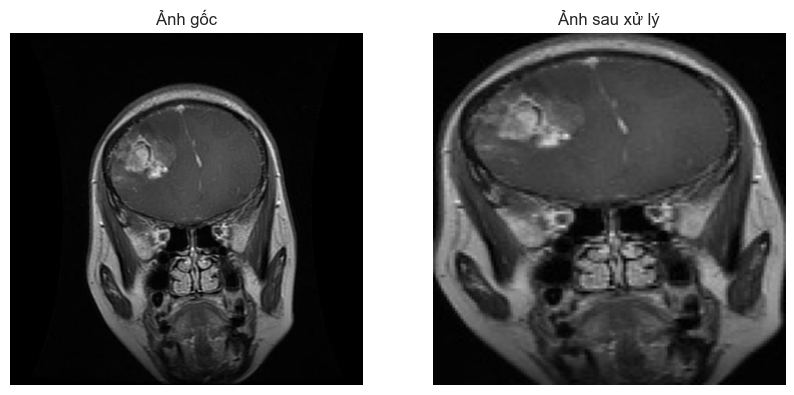

In [4]:
# HIỂN THỊ ẢNH MẪU TRƯỚC VÀ SAU KHI XỬ LÝ
sample_class = os.listdir(training)[0]
sample_img_name = os.listdir(os.path.join(training, sample_class))[0]

# Đường dẫn ảnh gốc và ảnh đã xử lý
raw_img_path = os.path.join(training, sample_class, sample_img_name)
cleaned_img_path = os.path.join(BASE_DIR, "data", "cleaned", "Training", sample_class, sample_img_name)

# Đọc ảnh
raw_img = cv2.cvtColor(cv2.imread(raw_img_path), cv2.COLOR_BGR2RGB)
cleaned_img = cv2.cvtColor(cv2.imread(cleaned_img_path), cv2.COLOR_BGR2RGB)

# Hiển thị
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(raw_img)
plt.title("Ảnh gốc")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cleaned_img)
plt.title("Ảnh sau xử lý")
plt.axis("off")

plt.show()

## 2. Chuẩn hóa dữ liệu.

### 2.1 Xử lý.

In [5]:
# HÀM ĐỌC DỮ LIỆU ẢNH
def load_images_from_folder(base_path):
    X, y = [], []
    classes = os.listdir(base_path)
    print(f"Các lớp tìm thấy: {classes}")

    for label in classes:
        folder = os.path.join(base_path, label)
        for file in tqdm(os.listdir(folder), desc=f"Đọc {label}", ncols=80, disable=True):
            if not file.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            img_path = os.path.join(folder, file)
            img = cv2.imread(img_path)
            if img is None:
                print(f"Ảnh lỗi: {file}")
                continue
            if img.shape != (128, 128, 3):
                print(f"Ảnh sai kích thước: {file}, shape={img.shape}")
                continue
            X.append(img)
            y.append(label)
    return np.array(X), np.array(y)

# MAIN
train_path = "data/cleaned/Training"
test_path = "data/cleaned/Testing"

if not os.path.exists(train_path) or not os.path.exists(test_path):
    print("Không tìm thấy thư mục dữ liệu. Kiểm tra lại đường dẫn!")
    print("Training:", os.path.abspath(train_path))
    print("Testing:", os.path.abspath(test_path))
    exit()

X_train, y_train = load_images_from_folder(train_path)
X_test, y_test = load_images_from_folder(test_path)

print("\nĐọc dữ liệu xong.")
print("Training:", X_train.shape, "Testing:", X_test.shape)
print("Số lớp:", len(np.unique(y_train)))
print("Các nhãn:", np.unique(y_train))

# Mã hoá nhãn
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

onehot_encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = onehot_encoder.fit_transform(y_train_encoded.reshape(-1, 1))
y_test_onehot = onehot_encoder.transform(y_test_encoded.reshape(-1, 1))

# Chuẩn hoá ảnh về [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print("\nThống kê dữ liệu sau chuẩn hoá:")
print("Train set:", X_train.shape, y_train_encoded.shape)
print("Test set:", X_test.shape, y_test_encoded.shape)
print("Giá trị pixel min:", np.min(X_train), "max:", np.max(X_train))
print("Số lớp:", len(label_encoder.classes_))
print("Tên lớp:", label_encoder.classes_)

Các lớp tìm thấy: ['glioma', 'meningioma', 'notumor', 'pituitary']
Các lớp tìm thấy: ['glioma', 'meningioma', 'notumor', 'pituitary']

Đọc dữ liệu xong.
Training: (5712, 128, 128, 3) Testing: (1311, 128, 128, 3)
Số lớp: 4
Các nhãn: ['glioma' 'meningioma' 'notumor' 'pituitary']

Thống kê dữ liệu sau chuẩn hoá:
Train set: (5712, 128, 128, 3) (5712,)
Test set: (1311, 128, 128, 3) (1311,)
Giá trị pixel min: 0.0 max: 1.0
Số lớp: 4
Tên lớp: ['glioma' 'meningioma' 'notumor' 'pituitary']


### 2.2 Biểu đồ mô tả trực quan

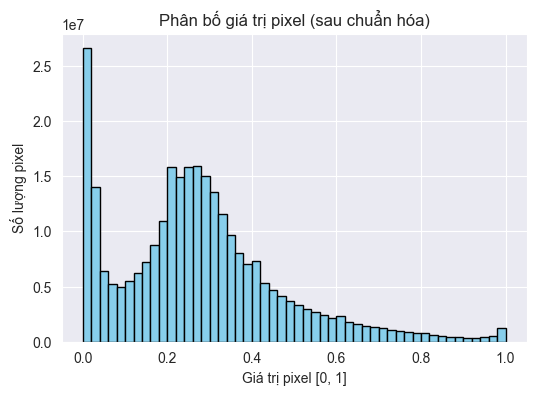

In [6]:
# Flatten toàn bộ pixel để xem histogram
pixels = X_train.flatten()

plt.figure(figsize=(6,4))
plt.hist(pixels, bins=50, color='skyblue', edgecolor='black')
plt.title("Phân bố giá trị pixel (sau chuẩn hóa)")
plt.xlabel("Giá trị pixel [0, 1]")
plt.ylabel("Số lượng pixel")
plt.show()

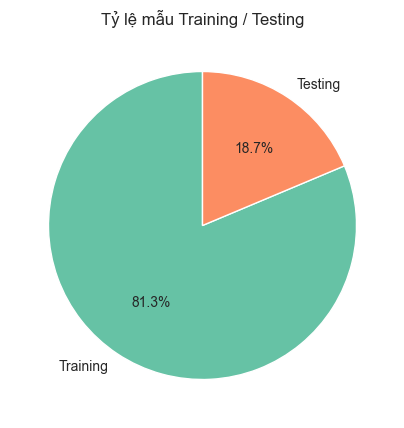

In [7]:
sizes = [len(y_train), len(y_test)]
labels = ['Training', 'Testing']

plt.figure(figsize=(5,5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#66c2a5','#fc8d62'])
plt.title("Tỷ lệ mẫu Training / Testing")
plt.show()

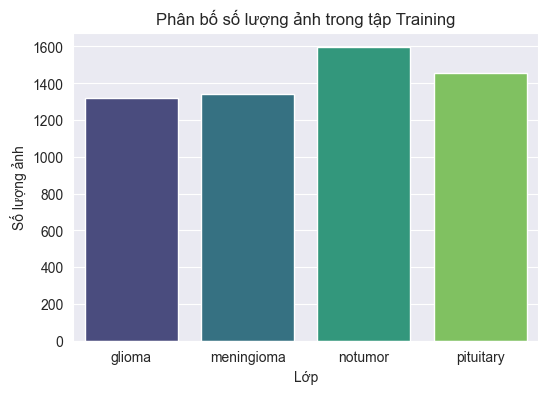

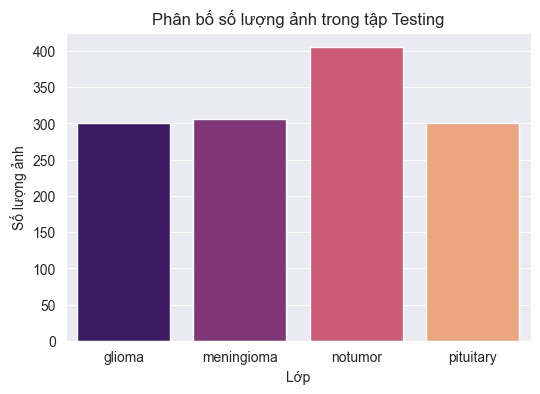

In [8]:
# Đếm số lượng ảnh mỗi lớp
train_counts = Counter(y_train)
test_counts = Counter(y_test)

# Tạo DataFrame
train_df = pd.DataFrame({
    "Lớp": list(train_counts.keys()),
    "Số lượng": list(train_counts.values())
})

test_df = pd.DataFrame({
    "Lớp": list(test_counts.keys()),
    "Số lượng": list(test_counts.values())
})

# Biểu đồ tập huấn luyện
plt.figure(figsize=(6,4))
sns.barplot(data=train_df, x="Lớp", y="Số lượng", hue="Lớp", palette="viridis", legend=False)
plt.title("Phân bố số lượng ảnh trong tập Training")
plt.xlabel("Lớp")
plt.ylabel("Số lượng ảnh")
plt.show()

# Biểu đồ tập kiểm tra
plt.figure(figsize=(6,4))
sns.barplot(data=test_df, x="Lớp", y="Số lượng", hue="Lớp", palette="magma", legend=False)
plt.title("Phân bố số lượng ảnh trong tập Testing")
plt.xlabel("Lớp")
plt.ylabel("Số lượng ảnh")
plt.show()

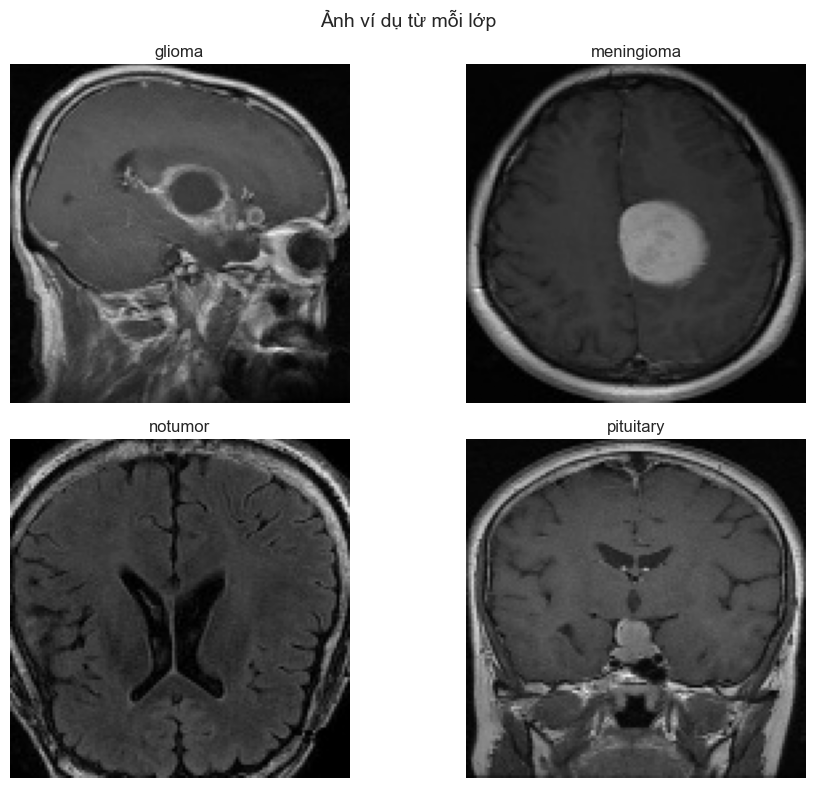

In [9]:
plt.figure(figsize=(10, 8))
classes = np.unique(y_train)
for i, label in enumerate(classes):
    img_idx = np.where(y_train == label)[0]
    img = X_train[random.choice(img_idx)]
    plt.subplot(2, 2, i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis('off')
plt.suptitle("Ảnh ví dụ từ mỗi lớp", fontsize=14)
plt.tight_layout()
plt.show()

# II. Phân tích và trực quan hóa dữ liệu.

In [10]:
# TRÍCH XUẤT HOG
def extract_hog_features(images):
    hog_features = []
    for img in images:
        # Chuyển sang grayscale vì HOG không cần màu
        gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_BGR2GRAY)

        # Tính HOG
        feat = hog(
            gray,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            transform_sqrt=True,
            feature_vector=True
        )
        hog_features.append(feat)
    return np.array(hog_features)

print("\nBắt đầu trích xuất HOG cho tập train...")
X_train_hog = extract_hog_features(X_train)

print("\nBắt đầu trích xuất HOG cho tập test...")
X_test_hog = extract_hog_features(X_test)

print("\nHoàn tất trích xuất HOG.")
print("Kích thước đặc trưng:")
print("X_train_hog:", X_train_hog.shape)
print("X_test_hog:", X_test_hog.shape)


Bắt đầu trích xuất HOG cho tập train...


Trích xuất HOG: 100%|██████████████████████| 5712/5712 [00:38<00:00, 148.19it/s]



Bắt đầu trích xuất HOG cho tập test...


Trích xuất HOG: 100%|██████████████████████| 1311/1311 [00:08<00:00, 152.11it/s]


Hoàn tất trích xuất HOG.
Kích thước đặc trưng:
X_train_hog: (5712, 8100)
X_test_hog: (1311, 8100)


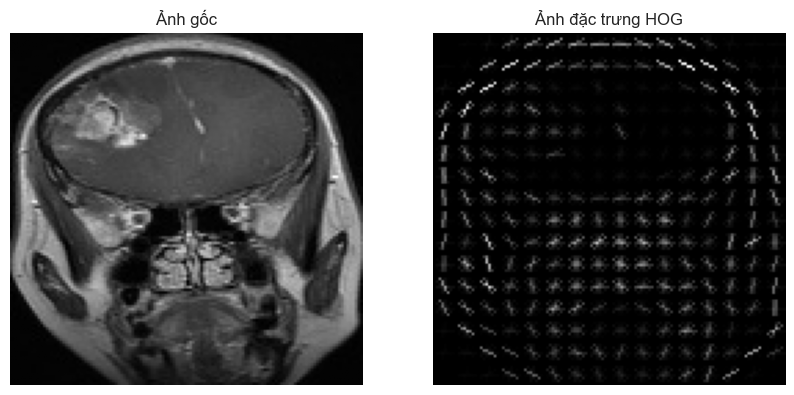

In [11]:
# Chọn 1 ảnh từ tập train
img = X_train[0]

# Chuyển sang grayscale
gray = rgb2gray(img)

# Tính HOG và ảnh trực quan hóa
features, hog_image = hog(
    gray,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm='L2-Hys',
    visualize=True,
    transform_sqrt=True
)

# Hiển thị
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title('Ảnh gốc')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(hog_image, cmap='gray')
plt.title('Ảnh đặc trưng HOG')
plt.axis('off')

plt.show()

## 2.1 Phân tích dữ liệu

--- Phân tích tập X_train_hog ---
Kích thước dữ liệu: (5712, 8100)
Tổng số đặc trưng: 46267200
Mean HOG feature: 0.1320
Std HOG feature:  0.1018
Min HOG feature:  0.0000
Max HOG feature:  1.0000
--------------------------------
--- Phân tích tập X_test_hog ---
Kích thước dữ liệu: (1311, 8100)
Tổng số đặc trưng: 10619100
Mean HOG feature: 0.1313
Std HOG feature:  0.1026
Min HOG feature:  0.0000
Max HOG feature:  1.0000
--------------------------------


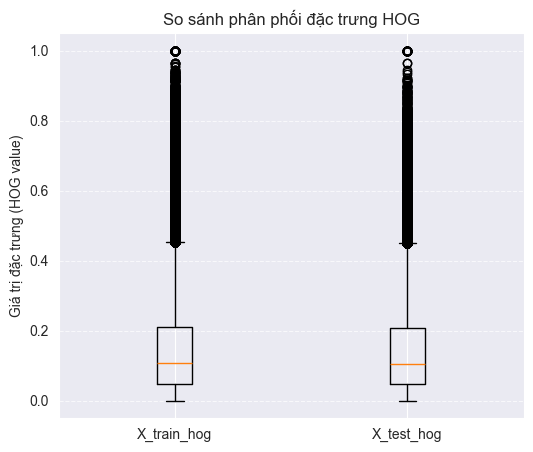

In [12]:
def analyze_hog_features(data, name):
    """
    Hàm này nhận vào một mảng HOG và tên của nó,
    sau đó in ra các thống kê và trả về mảng 1D đã được làm phẳng.
    """
    print(f"--- Phân tích tập {name} ---")

    # In kích thước
    print(f"Kích thước dữ liệu: {data.shape}")

    # Gộp tất cả các giá trị đặc trưng HOG lại
    all_features = data.flatten()
    print(f"Tổng số đặc trưng: {all_features.shape[0]}")

    # Tính thống kê
    mean_val = np.mean(all_features)
    std_val = np.std(all_features)
    min_val = np.min(all_features)
    max_val = np.max(all_features)

    print(f"Mean HOG feature: {mean_val:.4f}")
    print(f"Std HOG feature:  {std_val:.4f}")
    print(f"Min HOG feature:  {min_val:.4f}")
    print(f"Max HOG feature:  {max_val:.4f}")

    return all_features

# Phân tích cả hai tập
features_train = analyze_hog_features(X_train_hog, "X_train_hog")
print("-" * 32)
features_test = analyze_hog_features(X_test_hog, "X_test_hog")
print("-" * 32)

# ----- Vẽ Boxplot so sánh -----
plt.figure(figsize=(6, 5))

# Vẽ cả hai boxplot trên cùng một biểu đồ
plt.boxplot([features_train, features_test], tick_labels=['X_train_hog', 'X_test_hog'])

plt.title("So sánh phân phối đặc trưng HOG")
plt.ylabel("Giá trị đặc trưng (HOG value)")
plt.grid(axis='y', linestyle='--', alpha=0.7)

## 2.2 Giảm chiều và trực quan hóa dữ liệu.

### 2.2.1 Giảm chiều và trực quan hóa (PCA)

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_hog)
X_test_scaled = scaler.transform(X_test_hog)

pca_6 = PCA(n_components=6)
pca = PCA(n_components=0.9)

X_train_pca_6 = pca_6.fit_transform(X_train_scaled)
X_test_pca_6 = pca_6.transform(X_test_scaled)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Kích thước X_train sau PCA: {X_train_pca.shape}")
print(f"Kích thước X_test sau PCA: {X_test_pca.shape}")

Explained variance của từng thành phần PC1–PC6: [0.05786734 0.05690109 0.02502863 0.02324822 0.01724964 0.01304104]


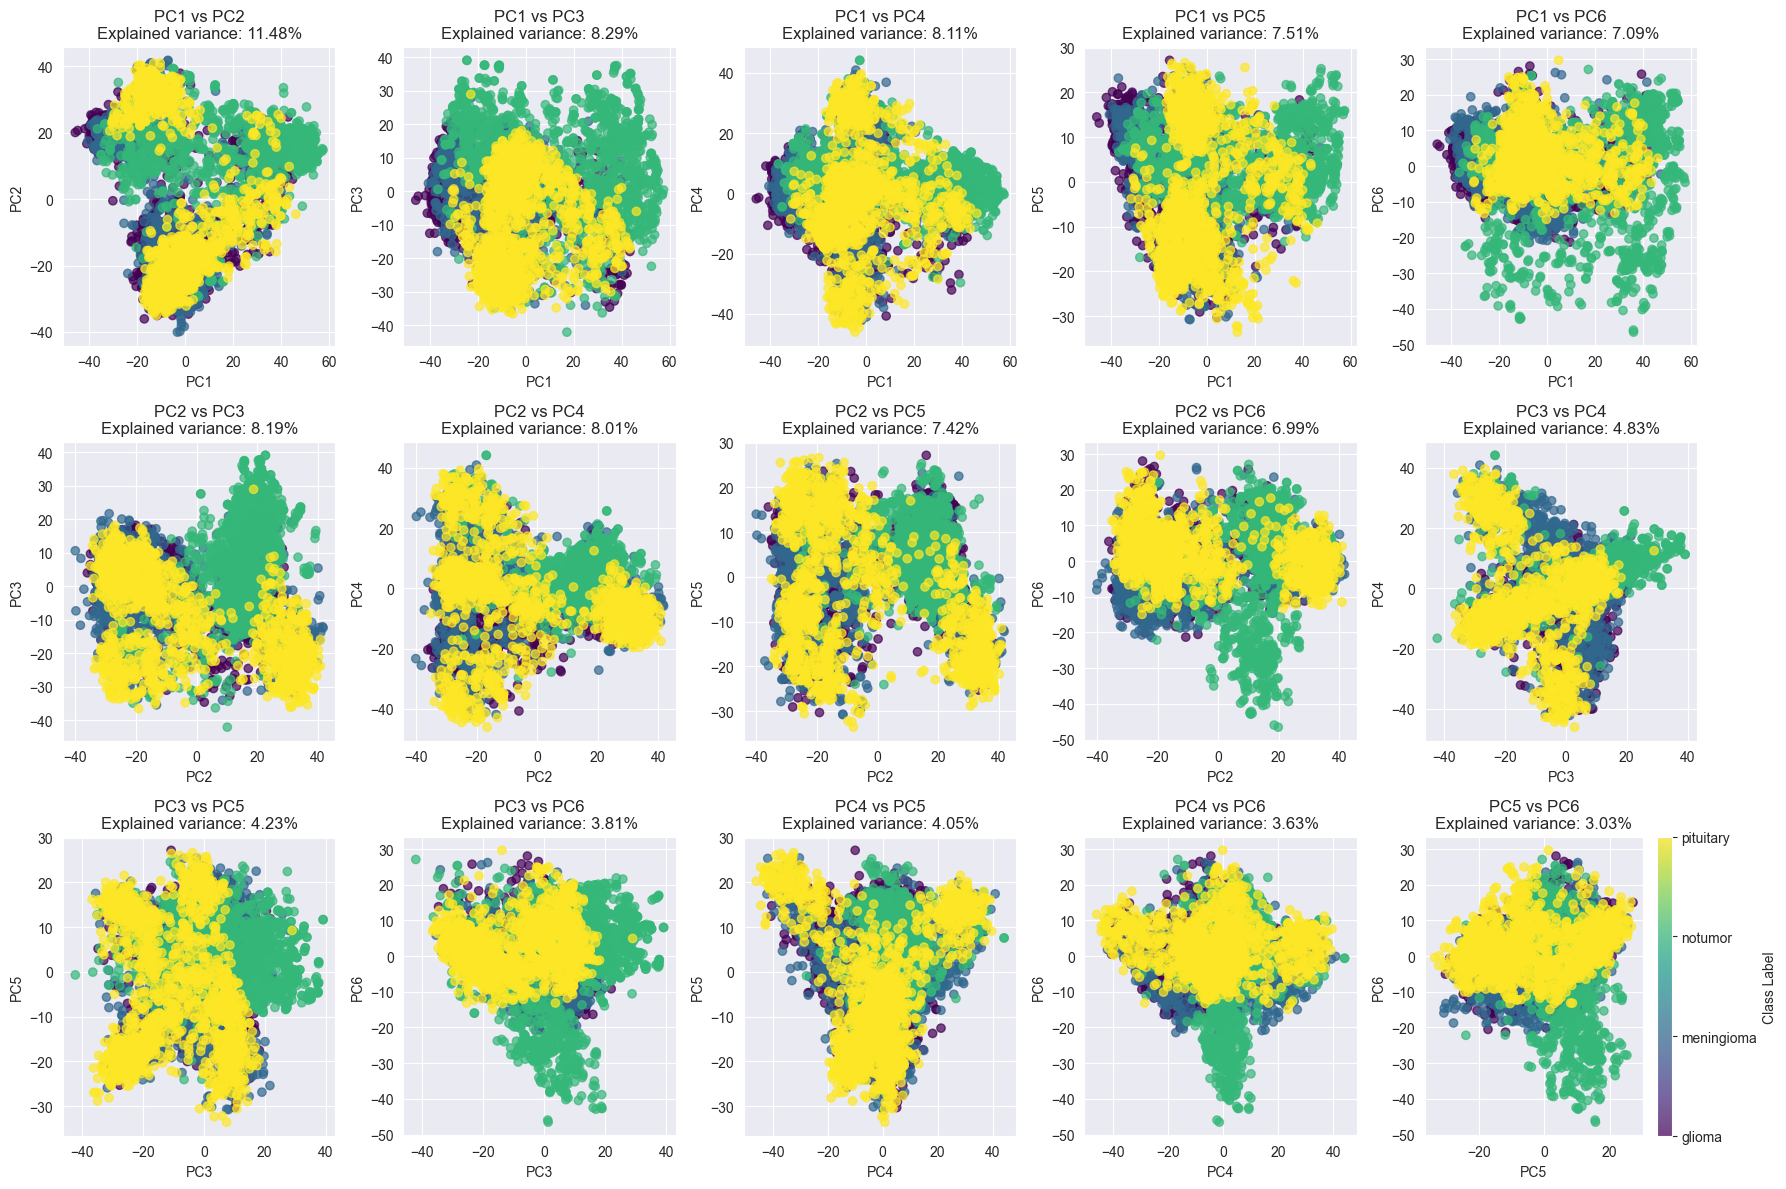

In [14]:
explained_var = pca_6.explained_variance_ratio_
print("Explained variance của từng thành phần PC1–PC6:", explained_var)
pairs = list(itertools.combinations(range(6), 2))

plt.figure(figsize=(18, 12))
for i, (x_idx, y_idx) in enumerate(pairs):
    plt.subplot(3, 5, i+1)
    scatter = plt.scatter(
        X_train_pca_6[:, x_idx], X_train_pca_6[:, y_idx],
        c=y_train_encoded, cmap='viridis', alpha=0.7
    )
    plt.xlabel(f"PC{x_idx+1}")
    plt.ylabel(f"PC{y_idx+1}")

    # Explained variance của cặp
    pair_var = explained_var[x_idx] + explained_var[y_idx]
    plt.title(f"PC{x_idx+1} vs PC{y_idx+1}\nExplained variance: {pair_var:.2%}")
    plt.grid(True)

class_names = label_encoder.classes_
cbar = plt.colorbar(scatter, ticks=range(len(class_names)))
cbar.ax.set_yticklabels(class_names)
cbar.set_label('Class Label')

plt.tight_layout()
plt.show()

Số thành phần PCA cần để giữ 90% thông tin: 1213


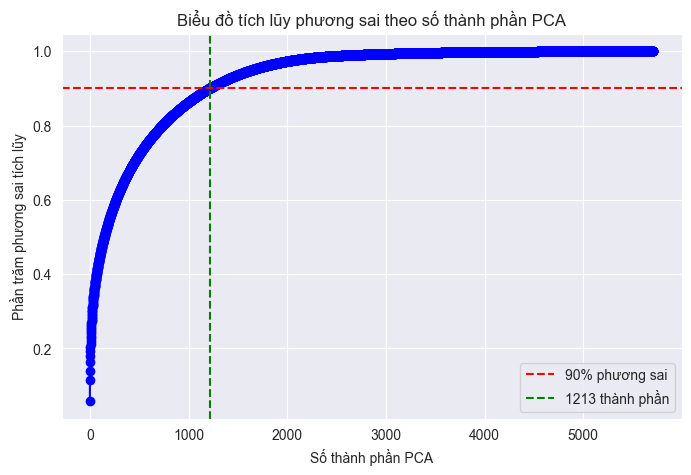

In [17]:
pca_full = PCA().fit(X_train_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

n_components_90 = np.argmax(cumulative_variance >= 0.9) + 1
print(f"Số thành phần PCA cần để giữ 90% thông tin: {n_components_90}")

plt.figure(figsize=(8,5))
plt.plot(cumulative_variance, marker='o', color='b')
plt.axhline(y=0.9, color='r', linestyle='--', label='90% phương sai')
plt.axvline(x=n_components_90, color='g', linestyle='--', label=f'{n_components_90} thành phần')
plt.title("Biểu đồ tích lũy phương sai theo số thành phần PCA")
plt.xlabel("Số thành phần PCA")
plt.ylabel("Phần trăm phương sai tích lũy")
plt.legend()
plt.grid(True)
plt.show()

### 2.2.2 Giảm chiều và trực quan hóa (LDA)

In [23]:
n_components = len(np.unique(y_train_encoded)) - 1
print(f"Số lớp của bài toán: {n_components + 1}")
print(f"Số chiều LDA sẽ giữ lại: {n_components}")

lda = LinearDiscriminantAnalysis(n_components=n_components)
X_train_lda = lda.fit_transform(X_train_scaled, y_train_encoded)
X_test_lda = lda.transform(X_test_scaled)

print(f"Kích thước X_train sau LDA: {X_train_lda.shape}")
print(f"Kích thước X_test sau LDA: {X_test_lda.shape}")

Số lớp của bài toán: 4
Số chiều LDA sẽ giữ lại (k = số lớp - 1): 3
Kích thước X_train sau LDA: (5712, 3)
Kích thước X_test sau LDA: (1311, 3)


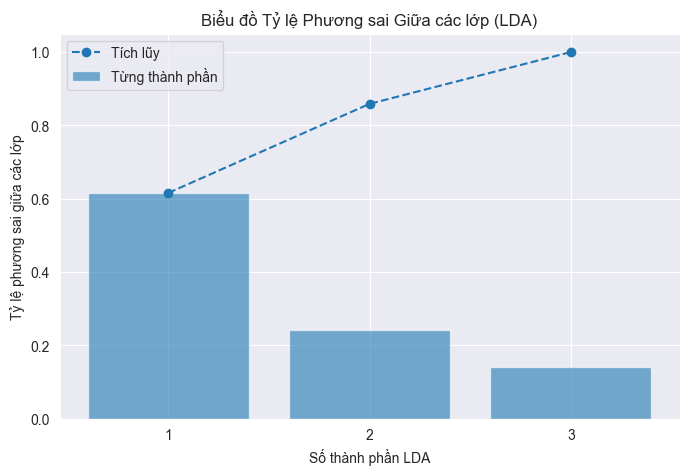

Tỷ lệ phương sai giữa các lớp: [0.61585565 0.24293523 0.14120911]


In [27]:
# Lấy tỷ lệ phương sai
explained_variance = lda.explained_variance_ratio_
# Tính tích lũy
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 5))
plt.plot(range(1, n_components + 1), cumulative_variance, marker='o', linestyle='--', label='Tích lũy')
plt.bar(range(1, n_components + 1), explained_variance, alpha=0.6, label='Từng thành phần')

plt.title('Biểu đồ Tỷ lệ Phương sai Giữa các lớp (LDA)')
plt.xlabel('Số thành phần LDA')
plt.ylabel('Tỷ lệ phương sai giữa các lớp')

plt.xticks(range(1, n_components + 1))
plt.legend()
plt.grid(True)
plt.show()

print(f"Tỷ lệ phương sai giữa các lớp: {explained_variance}")